In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy
from scripts.field_tracing import arcade

In [2]:
arc = arcade(Nx=256, Ny=128, fpx=(107,121,128,145), csheight=64, fluxratio=0.99)
%time arc.relax()

CPU times: user 1min 1s, sys: 8.49 ms, total: 1min 1s
Wall time: 1min 1s


In [3]:
# Do some reshuffling to get variables for plotting in the same space
field = (arc.stf.T) * -1 + 1
csheight = arc.csheight
cslev = arc.csval * -1 + 1

Nx = arc.Nx
Ny = arc.Ny

x = np.linspace(-1,1,Nx)
y = np.linspace(0,1,Ny)

csx = (arc.csx) / Ny - 1.0

clevels = np.linspace(0,1,20)

In [4]:
# Define a region around the reconnection current sheet
reczon = 0.15

def gen_circle(origin=[0,0], radius=1, angles=[0,2*np.pi], points=20):
    rads = np.linspace(angles[0], angles[1], points)
    x = radius * np.cos(rads) + origin[0]
    y = radius * np.sin(rads) + origin[1]
    return [x,y]

nseg = len(csx[csheight:])

arc_coords = gen_circle(origin=[csx[csheight], csheight / Ny], radius=reczon, angles=[np.pi, 2*np.pi], points=50)

rec_path_x = np.append(np.flip(csx[csheight:]) - reczon, np.append(arc_coords[0], csx[csheight:] + reczon))
rec_path_y = np.append(np.flip(np.arange(csheight,Ny)/Ny), np.append(arc_coords[1], np.arange(csheight,Ny)/Ny))

# Interpolate
f_int = scipy.interpolate.RectBivariateSpline(np.linspace(0,1,field.shape[0]), np.linspace(-1,1,field.shape[1]), field)

fp_vals = f_int.ev(rec_path_y, rec_path_x)

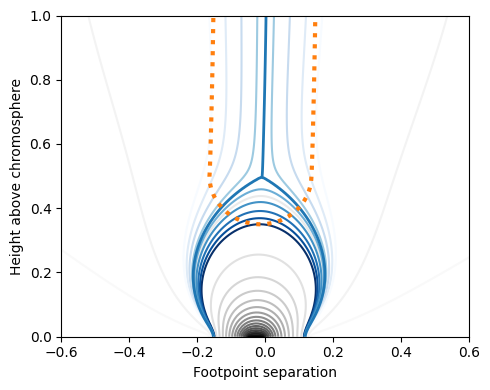

In [5]:
f, ax = plt.subplots(figsize=[5,4])
ax.contour(x, y, field, levels=clevels, cmap='Greys_r')
ax.contour(x, y, field, levels=np.linspace(fp_vals.min(), fp_vals.max(), 9), cmap="Blues_r")
ax.contour(x, y, field, levels=[cslev], colors='C0', linewidths=2)
ax.plot(csx[csheight:] + 0.005, np.arange(csheight,Ny)/Ny, 'C0', lw=2)

ax.plot(rec_path_x, rec_path_y, color='C1', linestyle=':', lw=3)

ax.set_xlabel('Footpoint separation')
ax.set_ylabel('Height above chromosphere')

ax.set_xlim(-0.6, 0.6)

plt.tight_layout()

plt.savefig('figures/field_connectivity.pdf')